In [ ]:
import numpy as np

from pygom import Event, Transition, SimulateOde
import matplotlib.pyplot as plt

from pygom.stochastic_solving.src.stochastic_sim.api import solve

# Stochastic solving

First we set up an SIR model with pygom.
The stochastic solver is not yet integrated into pygom class so we extract the necessary attributes and feed them in to the solver.

In [ ]:
N = 1e4
R0 = 1.5
gamma = 1/4.0
beta = R0 * gamma

# Params and states
params=['beta', 'gamma', 'N']
states=['S', 'I', 'R']

# State Limits (stochastic solver needs to know variable limits to assess illegal steps)
xlims = np.asarray([(0, N), (0, N), (0, N)], dtype=object)
mins = np.array([lim[0] if lim[0] is not None else -np.inf for lim in xlims])
maxs = np.array([lim[1] if lim[1] is not None else np.inf for lim in xlims])

# Transitions
transition_infection=Transition(origin='S', destination='I', transition_type='T', magnitude='1')
event_infection=Event(transition_list=[transition_infection], rate='beta*S*I/N')

transition_recovery=Transition(origin='I', destination='R', transition_type='T', magnitude='1')
event_recovery=Event(transition_list=[transition_recovery], rate='gamma*I')

model=SimulateOde(state=states, param=params, event=[event_infection, event_recovery])
model.parameters = {"beta": beta, "gamma": gamma, "N":N}

# Functions to input to solvers
transition_func = model.event_rate_vector           # rates at which events occur
state_change_mat = model.state_change_matrix        # state change as a result of each event
transition_mean_func = model.transition_mean        # (for adaptive tau) mean change of rates
transition_var_func = model.transition_variance     # (for adaptive tau) variance of change

## ################################
## SEIR model instead if interested
## ################################

# N = 1e5
# R0 = 1.3
# alpha = 1/2.0
# gamma = 1/4.0
# beta = R0 * gamma

# # Initial conditions
# i0 = 10
# x0 = np.array([N-i0, 0, i0, 0])

# # Params and states
# params=['beta', 'alpha', 'gamma', 'N']
# states=['S', 'E', 'I', 'R']

# # State Limits
# xlims = np.asarray([(0, N), (0, N), (0, N), (0, N)], dtype=object)
# mins = np.array([lim[0] if lim[0] is not None else -np.inf for lim in xlims])
# maxs = np.array([lim[1] if lim[1] is not None else np.inf for lim in xlims])

# # Transitions
# transition_infection=Transition(origin='S', destination='E', transition_type='T', magnitude='1')
# event_infection=Event(transition_list=[transition_infection], rate='beta*S*I/N')

# transition_progress=Transition(origin='E', destination='I', transition_type='T', magnitude='1')
# event_progress=Event(transition_list=[transition_progress], rate='alpha*E')

# transition_recovery=Transition(origin='I', destination='R', transition_type='T', magnitude='1')
# event_recovery=Event(transition_list=[transition_recovery], rate='gamma*I')

# model=SimulateOde(state=states, param=params, event=[event_infection, event_progress, event_recovery])
# model.parameters = {"beta": beta, "alpha": alpha, "gamma": gamma, "N":N}

# # Functions to input to solvers
# transition_func = model.event_rate_vector
# state_change_mat = model.state_change_matrix
# transition_mean_func = model.transition_mean
# transition_var_func = model.transition_variance

We need to select what stepper to use and perhaps provide parameters specific to that method. 

In [ ]:
from pygom.stochastic_solving.src.stochastic_sim.config import TauConfig, FixedTauConfig, Cao2006TauConfig
from pygom.stochastic_solving.src.stochastic_sim.config import ExactConfig, DirectMethodConfig

# Adaptive tau leap
algo_tau_adapt = TauConfig(method=Cao2006TauConfig(epsilon=0.03))

# Fixed tau leap
algo_tau_fixed = TauConfig(method=FixedTauConfig(tau=0.1))

# Direct reaction method
algo_direct = ExactConfig(method=DirectMethodConfig())

Tau leap algorithms also have options on:

1) Preemptively reducing tau if there is sufficient risk of an illegal step

In [ ]:
from pygom.stochastic_solving.src.stochastic_sim.config import ProbabilisticRefinerConfig

# e.g. refine the step size if there is a >0.05 chance of an illegal step occuring.
#      abandon if sufficiently small step size not found after 10 attempts 

algo_tau_adapt = TauConfig(
    method=FixedTauConfig(tau=0.1),
    refiner=ProbabilisticRefinerConfig(max_retries=10,
                                       acceptable_prob_misstep=0.05)
                                       )

2) Checking if a step is legal

In [ ]:
from pygom.stochastic_solving.src.stochastic_sim.config import CriticalReactionConfig

# e.g. check that transitions do not occur more than they possibly can (this
#      is different from checking that the states are legal)

algo_tau_adapt = TauConfig(
    method=FixedTauConfig(tau=0.1),
    checker=CriticalReactionConfig()
    )

3) Retrying a step if it resulted in an illegal state

In [ ]:
# e.g. retry an illegal step at most 10 times by shortening the time step
#      by a factor 0.5 each time

algo_tau_adapt = TauConfig(
    method=FixedTauConfig(tau=0.1),
    retry_max=10, tau_rescale=0.5
    )

# Now lets reset to default ....
algo_tau_adapt = TauConfig(method=Cao2006TauConfig(epsilon=0.03))

Solving functionality forms its own separate package.

In future, we would want some interface between pygom and the solver begind the scenes which is called by the user as before via something like model.solve().

For this example we pass everything to the solver directly.

In [ ]:
# Initial conditions
i0 = 10
x0 = np.array([N-i0, i0, 0])

# Solve stochastic time evolution
sim = solve(
    x0=x0,
    t_max=10000,                                    # set some large value so that max time doesn't cut simulation short (proceed_if_rates_zero must be False)
    ode_eqns=transition_func,
    state_change_mat=state_change_mat,
    x_min=mins, x_max=maxs,
    config=algo_tau_fixed,                          # stepper method (tau fixed / tau adaptive / exact direct / exact first etc....) plus relevant params
    perf=True,                                      # output performance diagnostics
    proceed_if_rates_zero=False,                    # stop the simulation when all rates = 0 (epidemic has ended)
    transition_mean_func=transition_mean_func,
    transition_var_func=transition_var_func
)

We can examine the outputs (there are post processing functions to bin the outputs and take snapshots etc but we'll skip for now).

First of all, since we selected perf=True, we can assess the performance

In [ ]:
sim.performance

PerformanceMetrics(wall_time_seconds=0.1063867000011669, cpu_time_seconds=0.109375)

We can see any diagnostic output, e.g. how many failed steps, did the simulation end prematurely

In [ ]:
sim.diag

TauLeapDiagnostics(zero_rate_termination=False, n_failed_step=0)

We can remind ourselves of what solver configuration we used

In [ ]:
sim.config

TauConfig(method=Cao2006TauConfig(epsilon=0.03), checker=CriticalReactionConfig(), refiner=NoRefinerConfig(), retry_max=10, tau_rescale=0.5)

And, of course, see the simualtion results

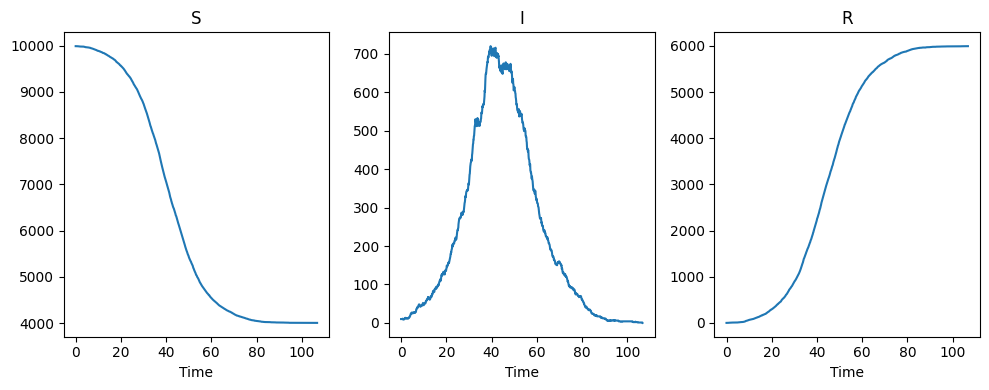

In [ ]:
fig, ax = plt.subplots(1, 3, figsize = (10, 4) )

for i in range(len(states)):
    ax[i].plot(sim.out.t, sim.out.x[:,i])
    ax[i].set_xlabel("Time")
    ax[i].set_title(states[i])
plt.tight_layout()
plt.show()

We solve with the direct reaction method:

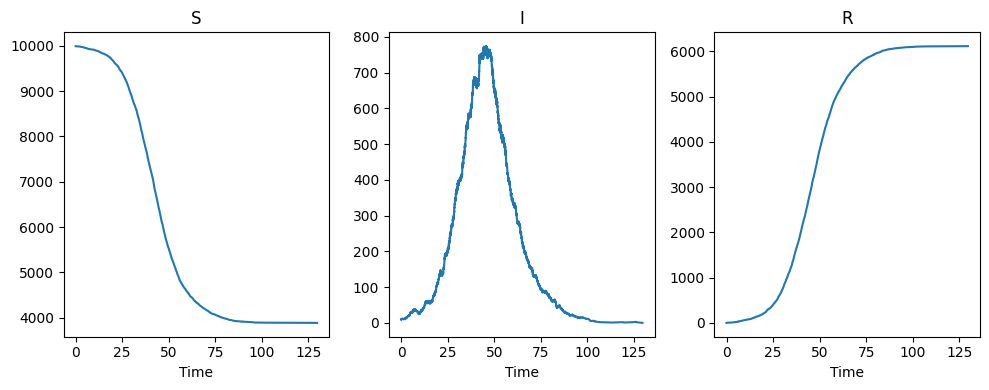

In [ ]:
sim = solve(
    x0=x0,
    t_max=10000,                                    # set some large value so that max time doesn't cut simulation short (proceed_if_rates_zero must be False)
    ode_eqns=transition_func,
    state_change_mat=state_change_mat,
    x_min=mins, x_max=maxs,
    config=algo_direct,                          # stepper method (tau fixed / tau adaptive / exact direct / exact first etc....) plus relevant params
    perf=True,                                      # output performance diagnostics
    proceed_if_rates_zero=False,                    # stop the simulation when all rates = 0 (epidemic has ended)
    transition_mean_func=transition_mean_func,
    transition_var_func=transition_var_func
)

fig, ax = plt.subplots(1, 3, figsize = (10, 4) )

for i in range(len(states)):
    ax[i].plot(sim.out.t, sim.out.x[:,i])
    ax[i].set_xlabel("Time")
    ax[i].set_title(states[i])
plt.tight_layout()
plt.show()

And adaptive tau

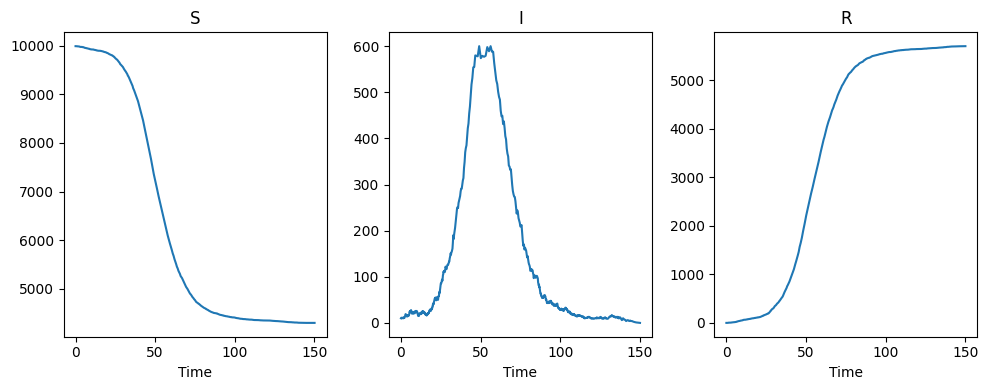

In [ ]:
sim = solve(
    x0=x0,
    t_max=10000,                                    # set some large value so that max time doesn't cut simulation short (proceed_if_rates_zero must be False)
    ode_eqns=transition_func,
    state_change_mat=state_change_mat,
    x_min=mins, x_max=maxs,
    config=algo_tau_adapt,                          # stepper method (tau fixed / tau adaptive / exact direct / exact first etc....) plus relevant params
    perf=True,                                      # output performance diagnostics
    proceed_if_rates_zero=False,                    # stop the simulation when all rates = 0 (epidemic has ended)
    transition_mean_func=transition_mean_func,
    transition_var_func=transition_var_func
)

fig, ax = plt.subplots(1, 3, figsize = (10, 4) )

for i in range(len(states)):
    ax[i].plot(sim.out.t, sim.out.x[:,i])
    ax[i].set_xlabel("Time")
    ax[i].set_title(states[i])
plt.tight_layout()
plt.show()

# Benchmarking

Questions then naturally arise:

1) What features should our stochastic solver be able to recover, e.g:
- Final size distribution (mean and SD over many simulation)
- Probability of stochastic extinction
- Doubling time

2) How do the above solver methods compare in terms of:
- Ability to replicate the above benchmarks (or perhaps specialisation towards a particular one)
- Computational resources

This is left to other notebooks